# Regime Switching and MS-GARCH Parameter Analysis

This notebook analyzes regime switching and MS-GARCH parameters to understand:
- How often we are in each regime
- Parameter differences between regimes
- Transition dynamics and regime persistence
- Volatility patterns across regimes

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load the data
rs_params = pd.read_csv('data/output/regime_switching_parameters.csv')
ms_garch = pd.read_csv('data/output/ms_garch_parameters.csv')

# Convert date columns to datetime
rs_params['date'] = pd.to_datetime(rs_params['date'])
ms_garch['date'] = pd.to_datetime(ms_garch['date'])

print('Regime Switching Parameters:')
print(f'Shape: {rs_params.shape}')
print(f'Date range: {rs_params["date"].min()} to {rs_params["date"].max()}')
print(f'Number of companies: {rs_params["gvkey"].nunique()}')
print()
print('MS-GARCH Parameters:')
print(f'Shape: {ms_garch.shape}')
print(f'Date range: {ms_garch["date"].min()} to {ms_garch["date"].max()}')
print(f'Number of companies: {ms_garch["gvkey"].nunique()}')

Regime Switching Parameters:
Shape: (2924, 14)
Date range: 2017-11-30 00:00:00 to 2024-12-31 00:00:00
Number of companies: 34

MS-GARCH Parameters:
Shape: (2924, 18)
Date range: 2017-11-30 00:00:00 to 2024-12-31 00:00:00
Number of companies: 34


In [3]:
# Display first few rows of each dataset
print('Regime Switching Parameters - First 5 rows:')
display(rs_params.head())

print('\nMS-GARCH Parameters - First 5 rows:')
display(ms_garch.head())

Regime Switching Parameters - First 5 rows:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
0,14447,2017-11-30,0.000480,-0.000339,0.009007,0.013924,4.069857,9.499876,0.996775,0.003225,0.007686,0.992314,0.0,0.0
1,14447,2017-12-29,0.000439,-0.000314,0.008955,0.013896,4.037076,9.260204,0.996843,0.003157,0.007013,0.992987,0.0,0.0
2,14447,2018-01-31,0.000412,-0.000356,0.009167,0.014098,3.980186,11.604357,0.998325,0.001675,0.006726,0.993274,0.0,0.0
3,14447,2018-02-28,0.000429,-0.000439,0.009056,0.014331,4.113808,10.690180,0.995769,0.004231,0.009968,0.990032,0.0,0.0
4,14447,2018-03-30,0.000416,-0.000411,0.009074,0.014323,4.049063,8.684741,0.996529,0.003471,0.008526,0.991474,0.0,0.0



MS-GARCH Parameters - First 5 rows:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,p00,p11,nu_0,nu_1,log_likelihood,aic,bic,n_obs
0,14447,2017-11-30,4.477372e-08,0.027518,0.971479,9.057309e-07,0.267801,0.633286,0.000166,0.001043,0.956088,0.949053,29.645517,2.829310,-7603.756301,15231.512601,15293.179005,1260
1,14447,2017-12-29,4.477372e-08,0.027518,0.971479,9.057309e-07,0.267801,0.633286,0.000166,0.001043,0.956088,0.949053,29.645517,2.829310,-7604.186696,15232.373393,15294.039797,1260
2,14447,2018-01-31,4.477405e-08,0.027519,0.971481,9.058138e-07,0.267876,0.633422,0.000166,0.001043,0.956096,0.949040,29.643906,2.829427,-7609.846843,15243.693687,15305.360091,1260
3,14447,2018-02-28,4.477405e-08,0.027519,0.971481,9.058138e-07,0.267876,0.633422,0.000166,0.001043,0.956096,0.949040,29.643906,2.829427,-7613.538900,15251.077801,15312.744205,1260
4,14447,2018-03-30,4.477405e-08,0.027519,0.971481,9.058138e-07,0.267876,0.633422,0.000166,0.001043,0.956096,0.949040,29.643906,2.829427,-7622.101057,15268.202113,15329.868517,1260


In [4]:
# Summary statistics
print('Regime Switching - Summary Statistics:')
display(rs_params.describe())

print('\nMS-GARCH - Summary Statistics:')
display(ms_garch.describe())

Regime Switching - Summary Statistics:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
count,2924.000000,2924,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.0,2924.0
mean,96970.441176,2021-06-14 21:12:33.488372,0.000291,-0.000249,0.005873,0.016224,15.264746,11.854458,0.959937,0.040063,0.055861,0.944139,0.0,0.0
min,14447.000000,2017-11-30 00:00:00,-0.002444,-0.005262,0.000006,0.000933,2.136001,2.001000,0.039318,0.001000,0.001000,0.184144,0.0,0.0
25%,17452.000000,2019-08-30 00:00:00,0.000048,-0.000438,0.003452,0.008807,3.701237,2.664106,0.977058,0.004236,0.009310,0.944687,0.0,0.0
50%,100330.500000,2021-06-15 00:00:00,0.000201,-0.000127,0.005927,0.013547,4.287620,3.866969,0.991009,0.008991,0.026118,0.973882,0.0,0.0
75%,132740.000000,2023-03-31 00:00:00,0.000506,0.000049,0.007906,0.019643,5.587827,5.520969,0.995764,0.022942,0.055313,0.990690,0.0,0.0
max,241637.000000,2024-12-31 00:00:00,0.002127,0.005389,0.019013,0.044817,405.428793,405.428793,0.999000,0.960682,0.815856,0.999000,0.0,0.0
std,79558.739886,NaN,0.000455,0.000760,0.003802,0.011091,63.071160,54.550150,0.136497,0.136497,0.109717,0.109717,0.0,0.0



MS-GARCH - Summary Statistics:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,p00,p11,nu_0,nu_1,log_likelihood,aic,bic,n_obs
count,2924.000000,2924,2.924000e+03,2.924000e+03,2.924000e+03,2.924000e+03,2.924000e+03,2.924000e+03,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.000000,2924.0
mean,96970.441176,2021-06-14 21:12:33.488372,5.116183e-06,5.860620e-02,6.644254e-01,7.481391e-03,8.649785e-02,5.769405e-01,0.001380,0.001887,0.930295,0.864874,52.527264,3.729621,-6705.862739,13435.725478,13497.391882,1260.0
min,14447.000000,2017-11-30 00:00:00,1.497411e-15,3.257743e-78,2.192937e-39,1.524782e-12,2.417548e-22,6.232808e-13,-0.042670,-0.126693,0.000749,0.094278,2.000000,2.000000,-8430.152267,7721.411768,7783.078172,1260.0
25%,17452.000000,2019-08-30 00:00:00,7.991016e-08,1.946213e-02,3.192750e-02,9.058138e-07,1.713458e-03,4.793711e-02,-0.000103,-0.000022,0.936068,0.877145,4.294709,2.100069,-7475.163389,12931.549139,12993.215543,1260.0
50%,100330.500000,2021-06-15 00:00:00,5.144642e-07,4.704666e-02,9.079372e-01,6.771289e-06,1.903445e-02,7.321943e-01,0.000052,0.000332,0.977721,0.946755,6.056189,2.766525,-7100.743912,14225.487825,14287.154229,1260.0
75%,132740.000000,2023-03-31 00:00:00,1.788391e-06,8.016749e-02,9.519533e-01,5.750967e-05,1.599412e-01,9.549658e-01,0.000183,0.000875,0.992020,0.982890,17.823091,3.381303,-6453.774570,14974.326778,15035.993182,1260.0
max,241637.000000,2024-12-31 00:00:00,1.366505e-04,8.885686e-01,9.971888e-01,4.085457e+00,8.328279e-01,9.989062e-01,0.172227,0.207265,1.000000,1.000000,12107.884737,140.290058,-3848.705884,16884.304535,16945.970939,1260.0
std,79558.739886,NaN,1.382446e-05,6.830125e-02,4.039556e-01,1.036504e-01,1.247467e-01,3.887244e-01,0.020374,0.015350,0.141498,0.176227,378.424614,8.606452,1189.982216,2379.964433,2379.964433,0.0


## 3. Regime Frequency Analysis

Calculate how often we are in each regime using steady-state probabilities from the transition matrix.

In [5]:
def calculate_steady_state_probabilities(p00, p11):
    """
    Calculate steady-state probabilities for a 2-state Markov chain.
    
    For a transition matrix:
    P = [[p00, p01],
         [p10, p11]]
    
    Steady state: pi = pi * P
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    """
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    return pi_0, pi_1

# Calculate steady-state probabilities for regime switching
rs_params['steady_state_regime_0'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[0],
    axis=1
)
rs_params['steady_state_regime_1'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[1],
    axis=1
)

# Calculate for MS-GARCH
ms_garch['steady_state_regime_0'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[0],
    axis=1
)
ms_garch['steady_state_regime_1'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[1],
    axis=1
)

print('Regime Switching - Average Time in Each Regime:')
print(f'Regime 0: {rs_params["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {rs_params["steady_state_regime_1"].mean():.2%}')

print('\nMS-GARCH - Average Time in Each Regime:')
print(f'Regime 0: {ms_garch["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {ms_garch["steady_state_regime_1"].mean():.2%}')

Regime Switching - Average Time in Each Regime:
Regime 0: 67.84%
Regime 1: 32.16%

MS-GARCH - Average Time in Each Regime:
Regime 0: 63.45%
Regime 1: 36.55%


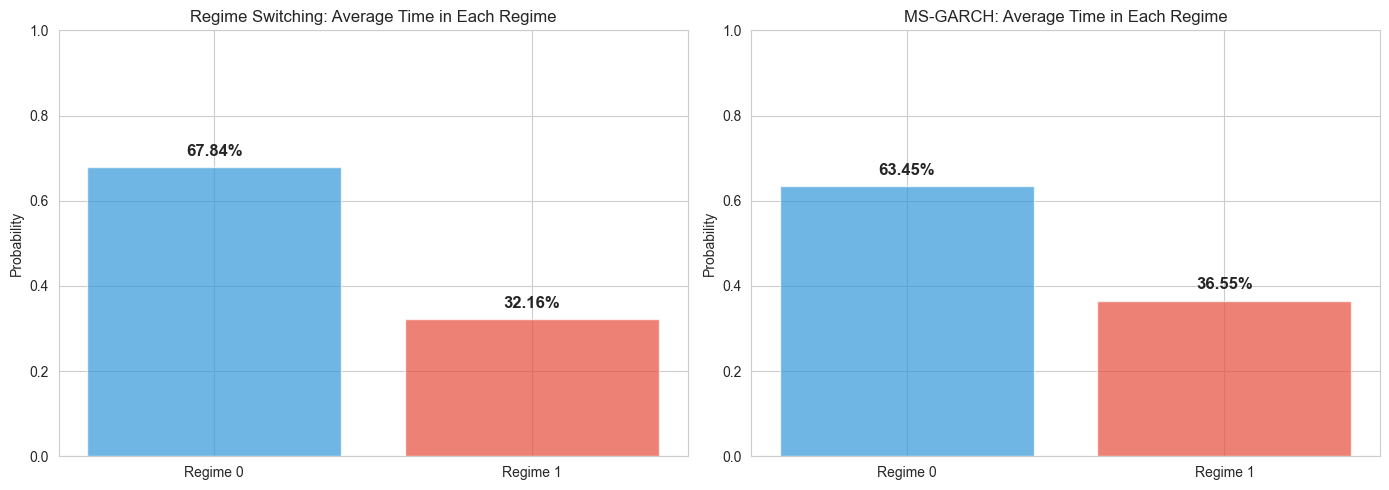

In [6]:
# Visualize regime frequencies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_regime_freq = rs_params[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].bar(['Regime 0', 'Regime 1'], rs_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Average Time in Each Regime')
axes[0].set_ylim([0, 1])
for i, v in enumerate(rs_regime_freq):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# MS-GARCH
ms_regime_freq = ms_garch[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].bar(['Regime 0', 'Regime 1'], ms_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Probability')
axes[1].set_title('MS-GARCH: Average Time in Each Regime')
axes[1].set_ylim([0, 1])
for i, v in enumerate(ms_regime_freq):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

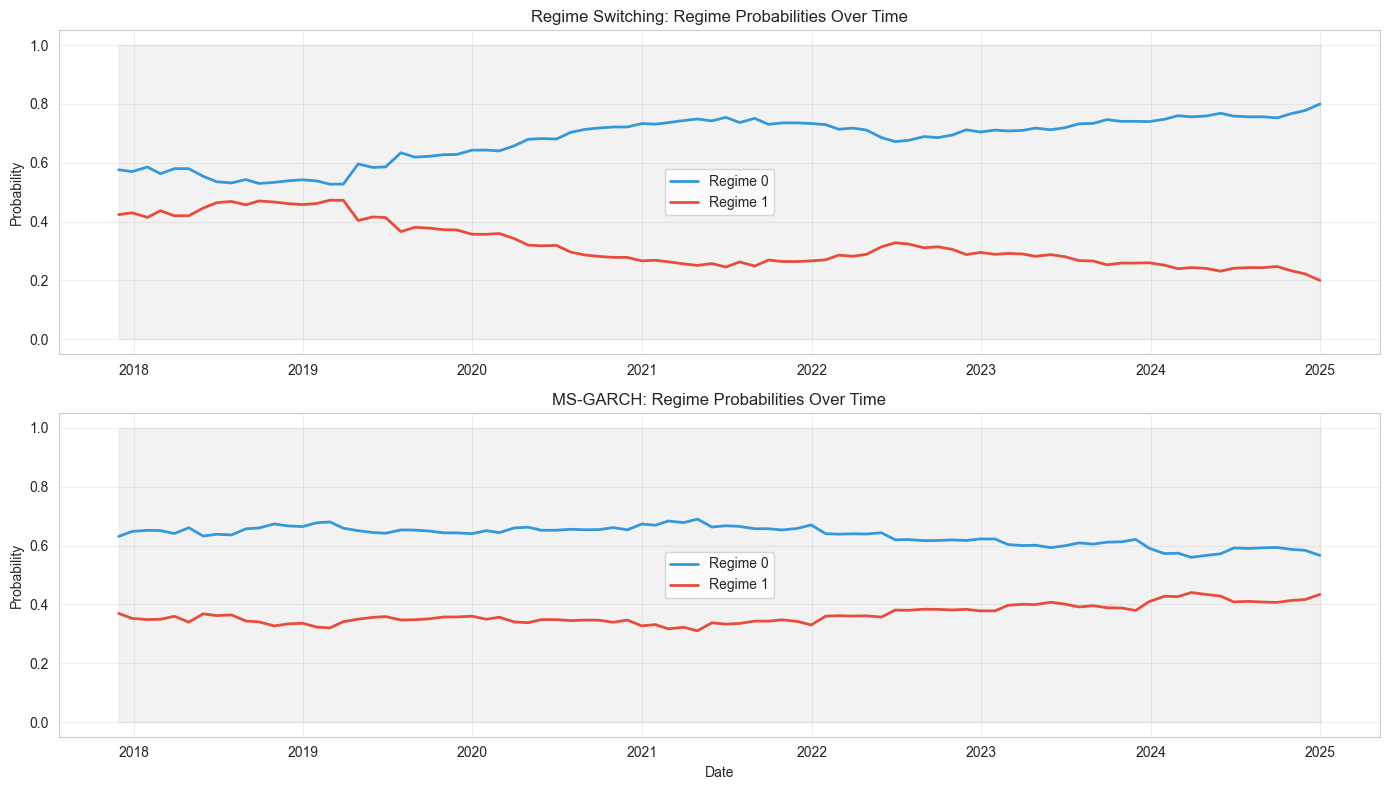

In [7]:
# Distribution of regime frequencies across time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Regime Switching over time
rs_time = rs_params.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].plot(rs_time.index, rs_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_time.index, rs_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_time.index, 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH over time
ms_time = ms_garch.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].plot(ms_time.index, ms_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[1].plot(ms_time.index, ms_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[1].fill_between(ms_time.index, 0, 1, alpha=0.1, color='gray')
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Probabilities Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Regime Duration Analysis

Expected duration in regime i: 1 / (1 - p_ii)

In [8]:
# Calculate expected durations
rs_params['duration_regime_0'] = 1 / (1 - rs_params['transition_prob_00'])
rs_params['duration_regime_1'] = 1 / (1 - rs_params['transition_prob_11'])

ms_garch['duration_regime_0'] = 1 / (1 - ms_garch['p00'])
ms_garch['duration_regime_1'] = 1 / (1 - ms_garch['p11'])

print('Regime Switching - Expected Duration (in periods):')
print(f'Regime 0: {rs_params["duration_regime_0"].mean():.2f} ± {rs_params["duration_regime_0"].std():.2f}')
print(f'Regime 1: {rs_params["duration_regime_1"].mean():.2f} ± {rs_params["duration_regime_1"].std():.2f}')

print('\nMS-GARCH - Expected Duration (in periods):')
print(f'Regime 0: {ms_garch["duration_regime_0"].mean():.2f} ± {ms_garch["duration_regime_0"].std():.2f}')
print(f'Regime 1: {ms_garch["duration_regime_1"].mean():.2f} ± {ms_garch["duration_regime_1"].std():.2f}')

Regime Switching - Expected Duration (in periods):
Regime 0: 190.25 ± 221.77
Regime 1: 98.19 ± 157.24

MS-GARCH - Expected Duration (in periods):
Regime 0: 83942.05 ± 3249601.96
Regime 1: 31813.52 ± 1709091.20


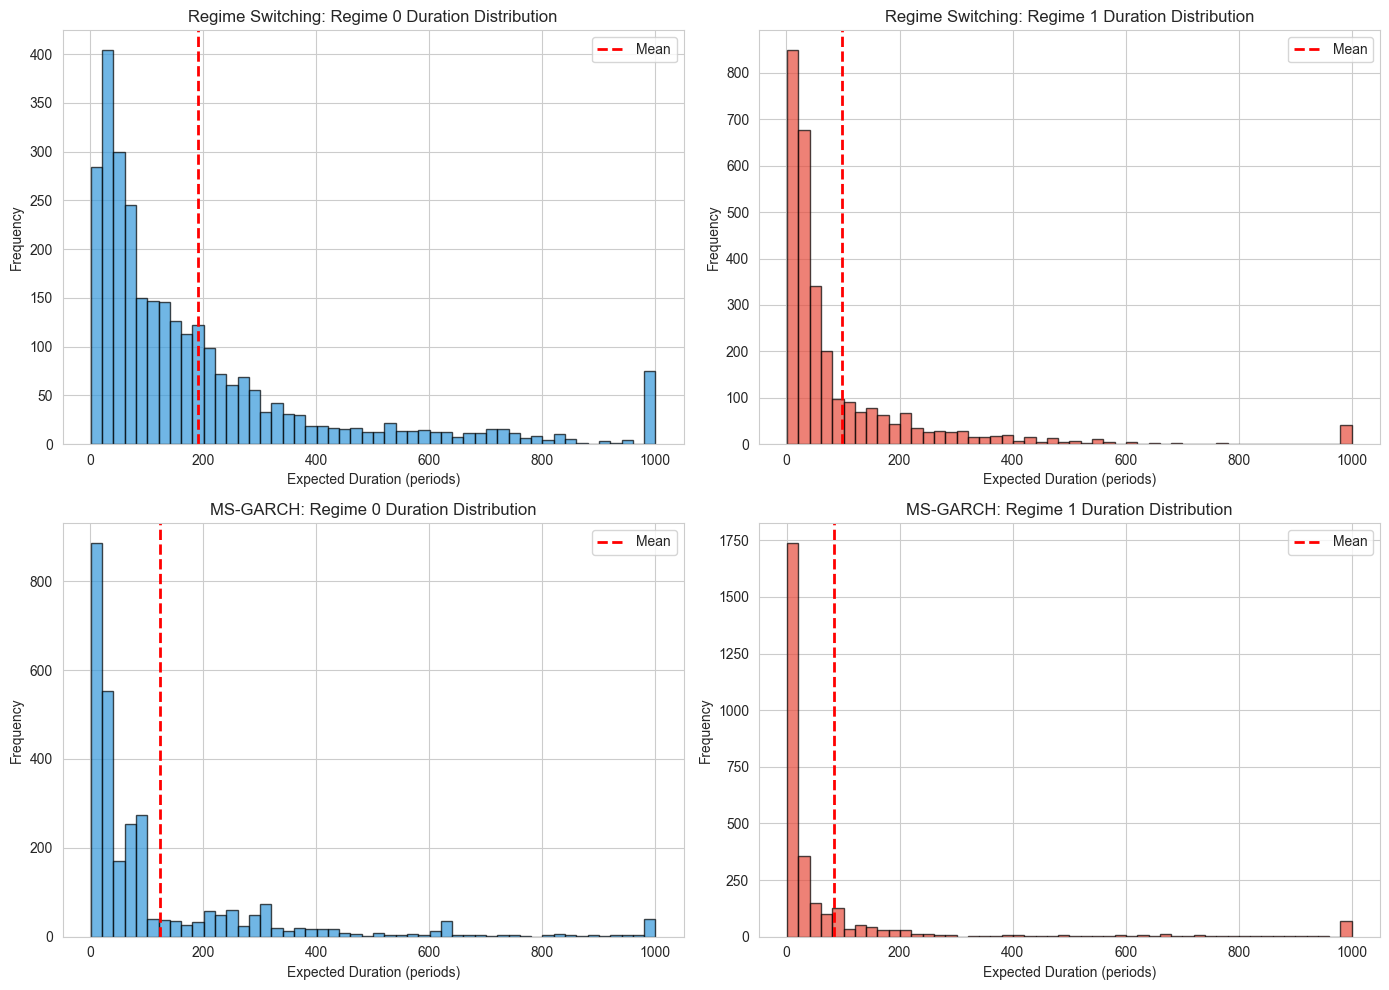


Note: Durations capped at 1000 periods for visualization
Infinite/extreme durations filtered:
  RS Regime 0: 0
  RS Regime 1: 0
  MS-GARCH Regime 0: 36
  MS-GARCH Regime 1: 70


In [9]:
# Visualize duration distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Filter out infinite values and cap durations for better visualization
def filter_duration(series, max_duration=1000):
    """Filter out infinite values and cap at max_duration for visualization"""
    return series.replace([np.inf, -np.inf], np.nan).clip(upper=max_duration)

# Regime Switching - Regime 0
rs_dur_0_filtered = filter_duration(rs_params['duration_regime_0'])
axes[0, 0].hist(rs_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Expected Duration (periods)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: Regime 0 Duration Distribution')
axes[0, 0].legend()

# Regime Switching - Regime 1
rs_dur_1_filtered = filter_duration(rs_params['duration_regime_1'])
axes[0, 1].hist(rs_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Expected Duration (periods)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: Regime 1 Duration Distribution')
axes[0, 1].legend()

# MS-GARCH - Regime 0
ms_dur_0_filtered = filter_duration(ms_garch['duration_regime_0'])
axes[1, 0].hist(ms_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Expected Duration (periods)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: Regime 0 Duration Distribution')
axes[1, 0].legend()

# MS-GARCH - Regime 1
ms_dur_1_filtered = filter_duration(ms_garch['duration_regime_1'])
axes[1, 1].hist(ms_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Expected Duration (periods)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: Regime 1 Duration Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print info about filtered values
print(f"\nNote: Durations capped at 1000 periods for visualization")
print(f"Infinite/extreme durations filtered:")
print(f"  RS Regime 0: {rs_params['duration_regime_0'].isna().sum() + (rs_params['duration_regime_0'] > 1000).sum()}")
print(f"  RS Regime 1: {rs_params['duration_regime_1'].isna().sum() + (rs_params['duration_regime_1'] > 1000).sum()}")
print(f"  MS-GARCH Regime 0: {ms_garch['duration_regime_0'].isna().sum() + (ms_garch['duration_regime_0'] > 1000).sum()}")
print(f"  MS-GARCH Regime 1: {ms_garch['duration_regime_1'].isna().sum() + (ms_garch['duration_regime_1'] > 1000).sum()}")

## 5. Parameter Comparison Between Regimes

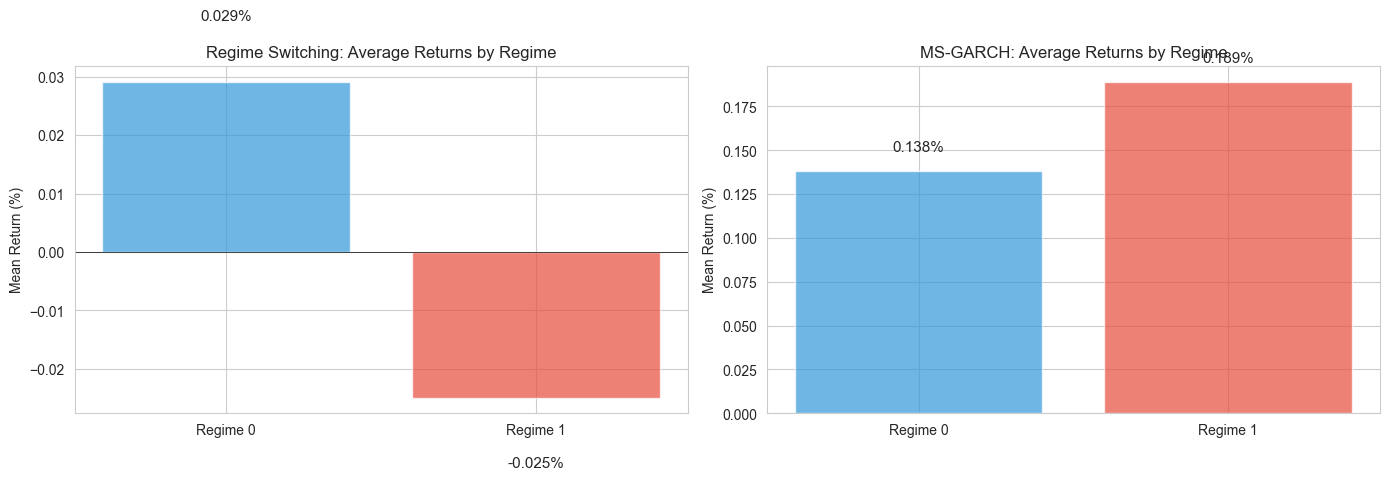

In [10]:
# Compare mean returns between regimes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_means = rs_params[['regime_0_mean', 'regime_1_mean']].mean() * 100  # Convert to percentage
axes[0].bar(['Regime 0', 'Regime 1'], rs_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Mean Return (%)')
axes[0].set_title('Regime Switching: Average Returns by Regime')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(rs_means):
    axes[0].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

# MS-GARCH
ms_means = ms_garch[['mu_0', 'mu_1']].mean() * 100
axes[1].bar(['Regime 0', 'Regime 1'], ms_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('MS-GARCH: Average Returns by Regime')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(ms_means):
    axes[1].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
# Detailed parameter comparison table
print('='*80)
print('REGIME SWITCHING MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_rs = pd.DataFrame({
    'Parameter': ['Mean Return', 'Volatility', 'Degrees of Freedom (nu)'],
    'Regime 0': [
        f"{rs_params['regime_0_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_0_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_0_nu'].mean():.2f}"
    ],
    'Regime 1': [
        f"{rs_params['regime_1_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_1_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean():.2f}"
    ],
    'Difference': [
        f"{(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%",
        f"{(rs_params['regime_1_vol'].mean() - rs_params['regime_0_vol'].mean())*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean() - rs_params['regime_0_nu'].mean():.2f}"
    ]
})
display(comparison_rs)

print('\n' + '='*80)
print('MS-GARCH MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_ms = pd.DataFrame({
    'Parameter': ['Mean Return', 'Degrees of Freedom (nu)', 'Omega', 'Alpha', 'Beta'],
    'Regime 0': [
        f"{ms_garch['mu_0'].mean()*100:.4f}%",
        f"{ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_0'].mean():.6f}",
        f"{ms_garch['alpha_0'].mean():.6f}",
        f"{ms_garch['beta_0'].mean():.6f}"
    ],
    'Regime 1': [
        f"{ms_garch['mu_1'].mean()*100:.4f}%",
        f"{ms_garch['nu_1'].mean():.2f}",
        f"{ms_garch['omega_1'].mean():.6f}",
        f"{ms_garch['alpha_1'].mean():.6f}",
        f"{ms_garch['beta_1'].mean():.6f}"
    ],
    'Ratio (R1/R0)': [
        f"{ms_garch['mu_1'].mean() / ms_garch['mu_0'].mean() if ms_garch['mu_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['nu_1'].mean() / ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_1'].mean() / ms_garch['omega_0'].mean() if ms_garch['omega_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['alpha_1'].mean() / ms_garch['alpha_0'].mean() if ms_garch['alpha_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['beta_1'].mean() / ms_garch['beta_0'].mean():.2f}"
    ]
})
display(comparison_ms)

REGIME SWITCHING MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Difference
0,Mean Return,0.0291%,-0.0249%,-0.0540%
1,Volatility,0.5873%,1.6224%,1.0351%
2,Degrees of Freedom (nu),15.26,11.85,-3.41



MS-GARCH MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Ratio (R1/R0)
0,Mean Return,0.1380%,0.1887%,1.37
1,Degrees of Freedom (nu),52.53,3.73,0.07
2,Omega,0.000005,0.007481,1462.30
3,Alpha,0.058606,0.086498,1.48
4,Beta,0.664425,0.576940,0.87


## 6. Volatility Analysis by Regime

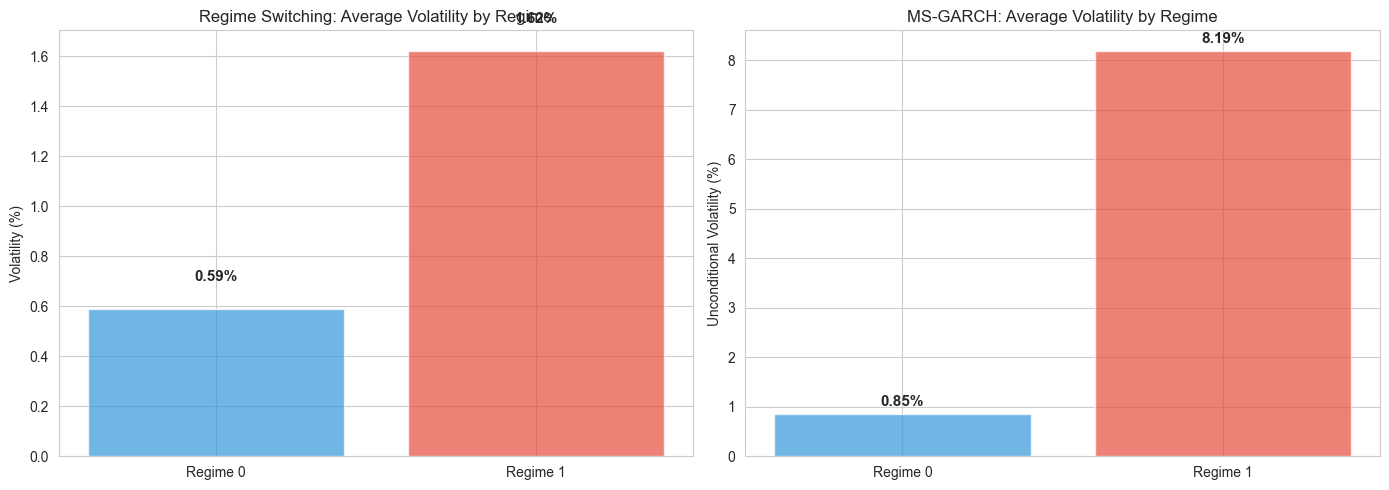

Regime Switching: Volatility Ratio (Regime 1 / Regime 0) = 2.76x
MS-GARCH: Volatility Ratio (Regime 1 / Regime 0) = 9.60x


In [12]:
# Volatility comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_vols = rs_params[['regime_0_vol', 'regime_1_vol']].mean() * 100
axes[0].bar(['Regime 0', 'Regime 1'], rs_vols, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title('Regime Switching: Average Volatility by Regime')
for i, v in enumerate(rs_vols):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# MS-GARCH - Calculate implied volatility from GARCH parameters
# Unconditional variance = omega / (1 - alpha - beta)
ms_garch['uncond_vol_0'] = np.sqrt(ms_garch['omega_0'] / (1 - ms_garch['alpha_0'] - ms_garch['beta_0']))
ms_garch['uncond_vol_1'] = np.sqrt(ms_garch['omega_1'] / (1 - ms_garch['alpha_1'] - ms_garch['beta_1']))

ms_vols = ms_garch[['uncond_vol_0', 'uncond_vol_1']].mean() * 100
axes[1].bar(['Regime 0', 'Regime 1'], ms_vols, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Unconditional Volatility (%)')
axes[1].set_title('MS-GARCH: Average Volatility by Regime')
for i, v in enumerate(ms_vols):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Regime Switching: Volatility Ratio (Regime 1 / Regime 0) = {rs_vols['regime_1_vol'] / rs_vols['regime_0_vol']:.2f}x")
print(f"MS-GARCH: Volatility Ratio (Regime 1 / Regime 0) = {ms_vols['uncond_vol_1'] / ms_vols['uncond_vol_0']:.2f}x")

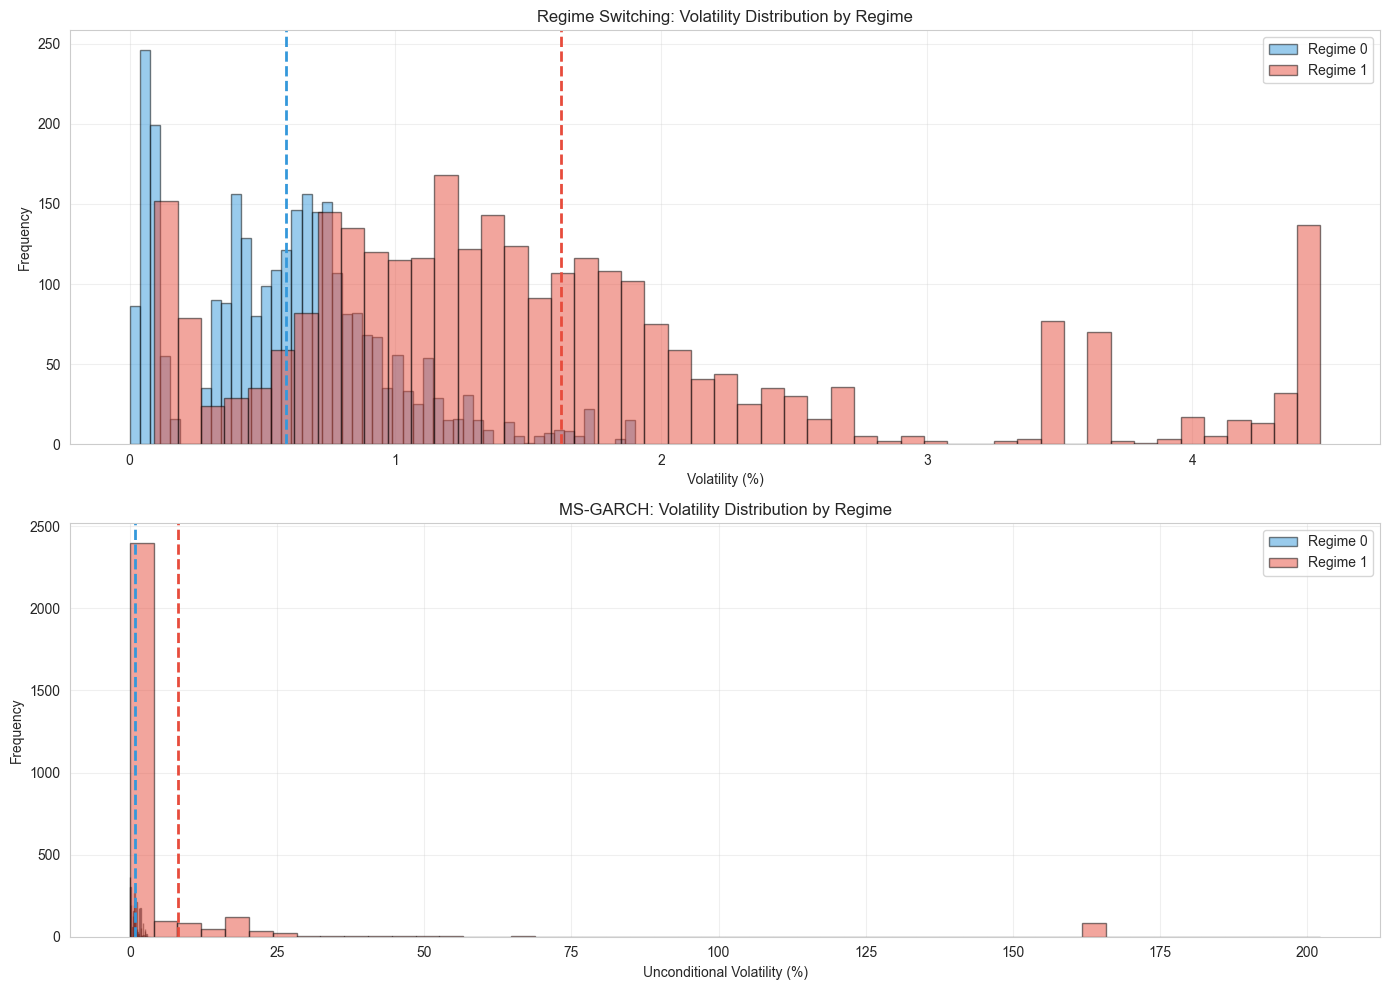

In [13]:
# Volatility distributions
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
axes[0].hist(rs_params['regime_0_vol']*100, bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[0].hist(rs_params['regime_1_vol']*100, bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[0].axvline(rs_params['regime_0_vol'].mean()*100, color='#3498db', linestyle='--', linewidth=2)
axes[0].axvline(rs_params['regime_1_vol'].mean()*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_xlabel('Volatility (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Regime Switching: Volatility Distribution by Regime')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH
axes[1].hist(ms_garch['uncond_vol_0']*100, bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[1].hist(ms_garch['uncond_vol_1']*100, bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[1].axvline(ms_garch['uncond_vol_0'].mean()*100, color='#3498db', linestyle='--', linewidth=2)
axes[1].axvline(ms_garch['uncond_vol_1'].mean()*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[1].set_xlabel('Unconditional Volatility (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('MS-GARCH: Volatility Distribution by Regime')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Transition Probability Analysis

In [14]:
# Analyze transition probabilities
print('='*80)
print('REGIME SWITCHING - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {rs_params['transition_prob_00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {rs_params['transition_prob_01'].mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {rs_params['transition_prob_10'].mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {rs_params['transition_prob_11'].mean():.4f}")

print('\n' + '='*80)
print('MS-GARCH - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {ms_garch['p00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {(1 - ms_garch['p00']).mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {(1 - ms_garch['p11']).mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {ms_garch['p11'].mean():.4f}")

REGIME SWITCHING - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.9599
P(switch to Regime 1 | in Regime 0): 0.0401
P(switch to Regime 0 | in Regime 1): 0.0559
P(stay in Regime 1 | in Regime 1): 0.9441

MS-GARCH - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.9303
P(switch to Regime 1 | in Regime 0): 0.0697
P(switch to Regime 0 | in Regime 1): 0.1351
P(stay in Regime 1 | in Regime 1): 0.8649


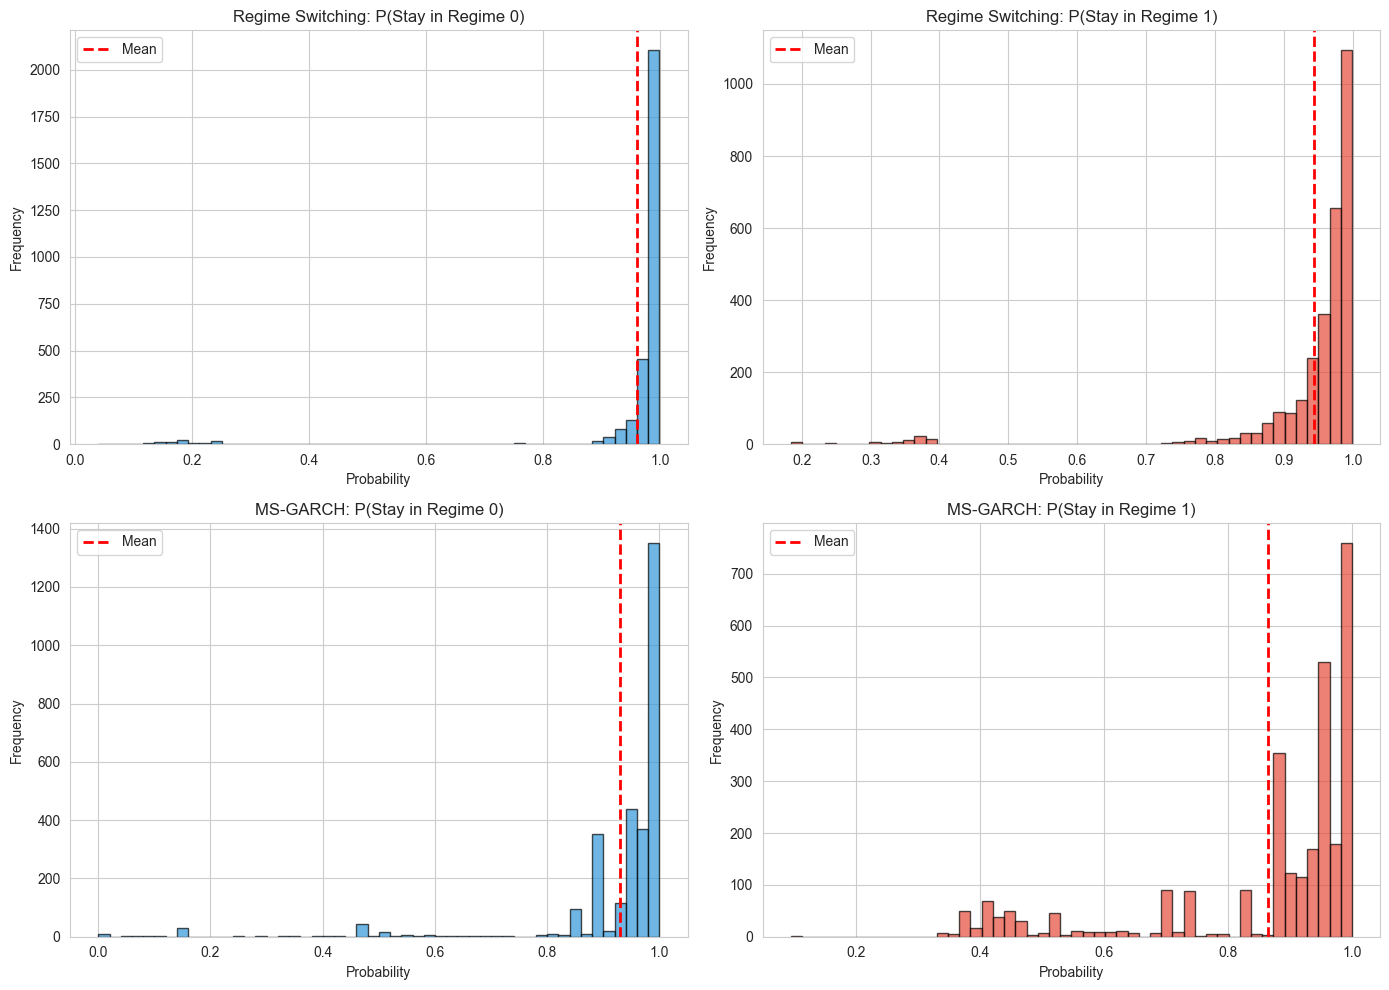

In [15]:
# Visualize transition probabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regime Switching - Persistence
axes[0, 0].hist(rs_params['transition_prob_00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_params['transition_prob_00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Probability')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: P(Stay in Regime 0)')
axes[0, 0].legend()

axes[0, 1].hist(rs_params['transition_prob_11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_params['transition_prob_11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: P(Stay in Regime 1)')
axes[0, 1].legend()

# MS-GARCH - Persistence
axes[1, 0].hist(ms_garch['p00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_garch['p00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: P(Stay in Regime 0)')
axes[1, 0].legend()

axes[1, 1].hist(ms_garch['p11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_garch['p11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: P(Stay in Regime 1)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

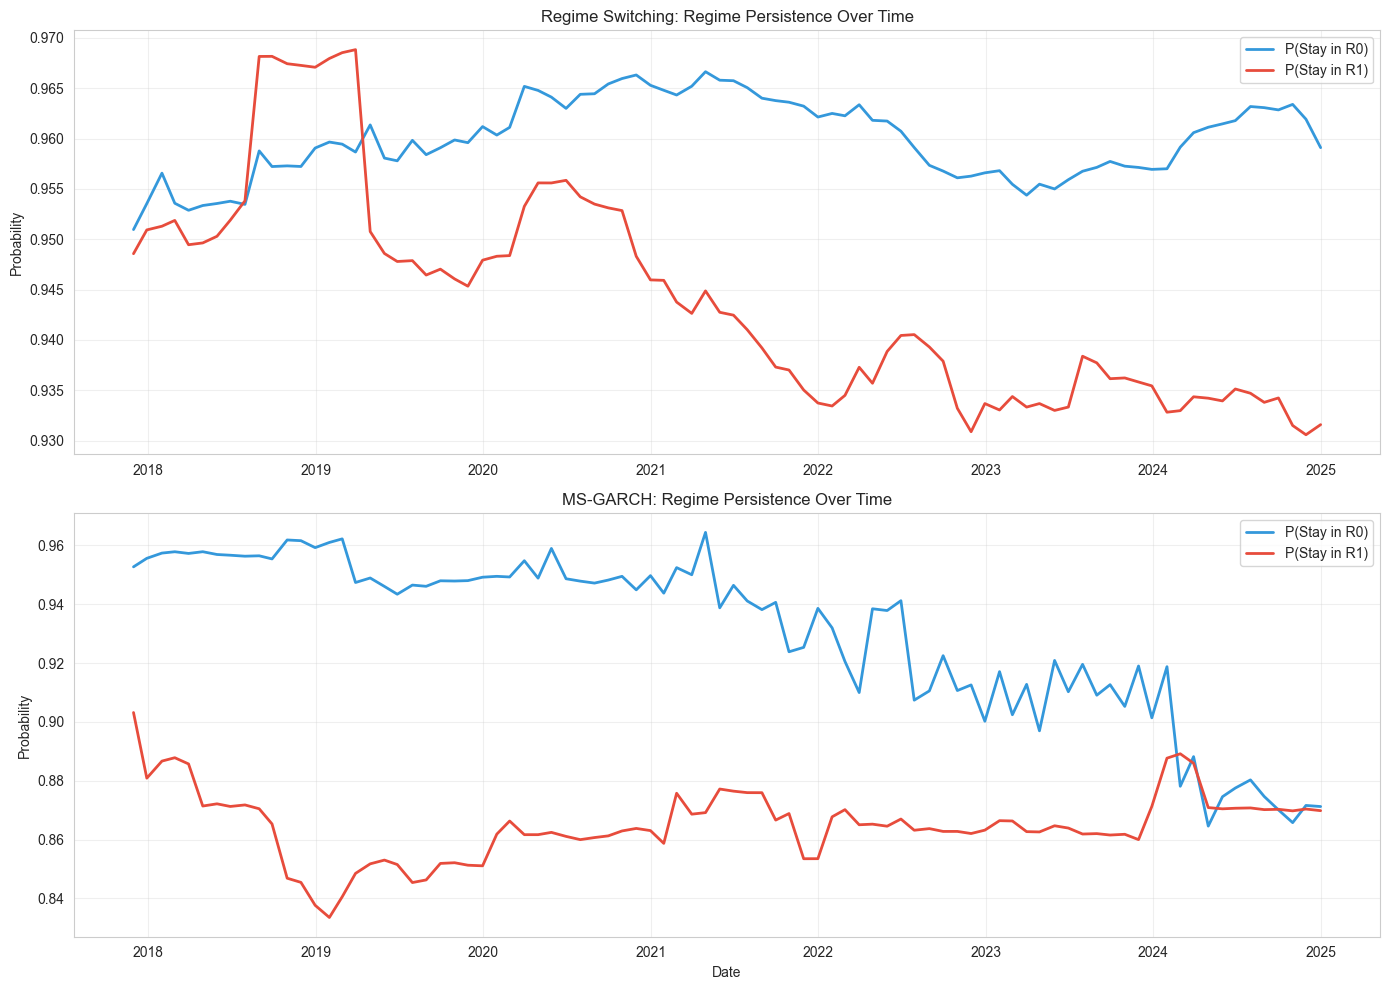

In [16]:
# Transition probabilities over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
rs_trans_time = rs_params.groupby('date')[['transition_prob_00', 'transition_prob_11']].mean()
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Persistence Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH
ms_trans_time = ms_garch.groupby('date')[['p00', 'p11']].mean()
axes[1].plot(ms_trans_time.index, ms_trans_time['p00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[1].plot(ms_trans_time.index, ms_trans_time['p11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Persistence Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Time Series Visualization of Regimes

Let's look at a specific company over time.

In [17]:
# Select a company to analyze
sample_gvkey = rs_params['gvkey'].iloc[0]
print(f"Analyzing company: {sample_gvkey}")

# Filter data for this company
rs_company = rs_params[rs_params['gvkey'] == sample_gvkey].sort_values('date')
ms_company = ms_garch[ms_garch['gvkey'] == sample_gvkey].sort_values('date')

Analyzing company: 14447


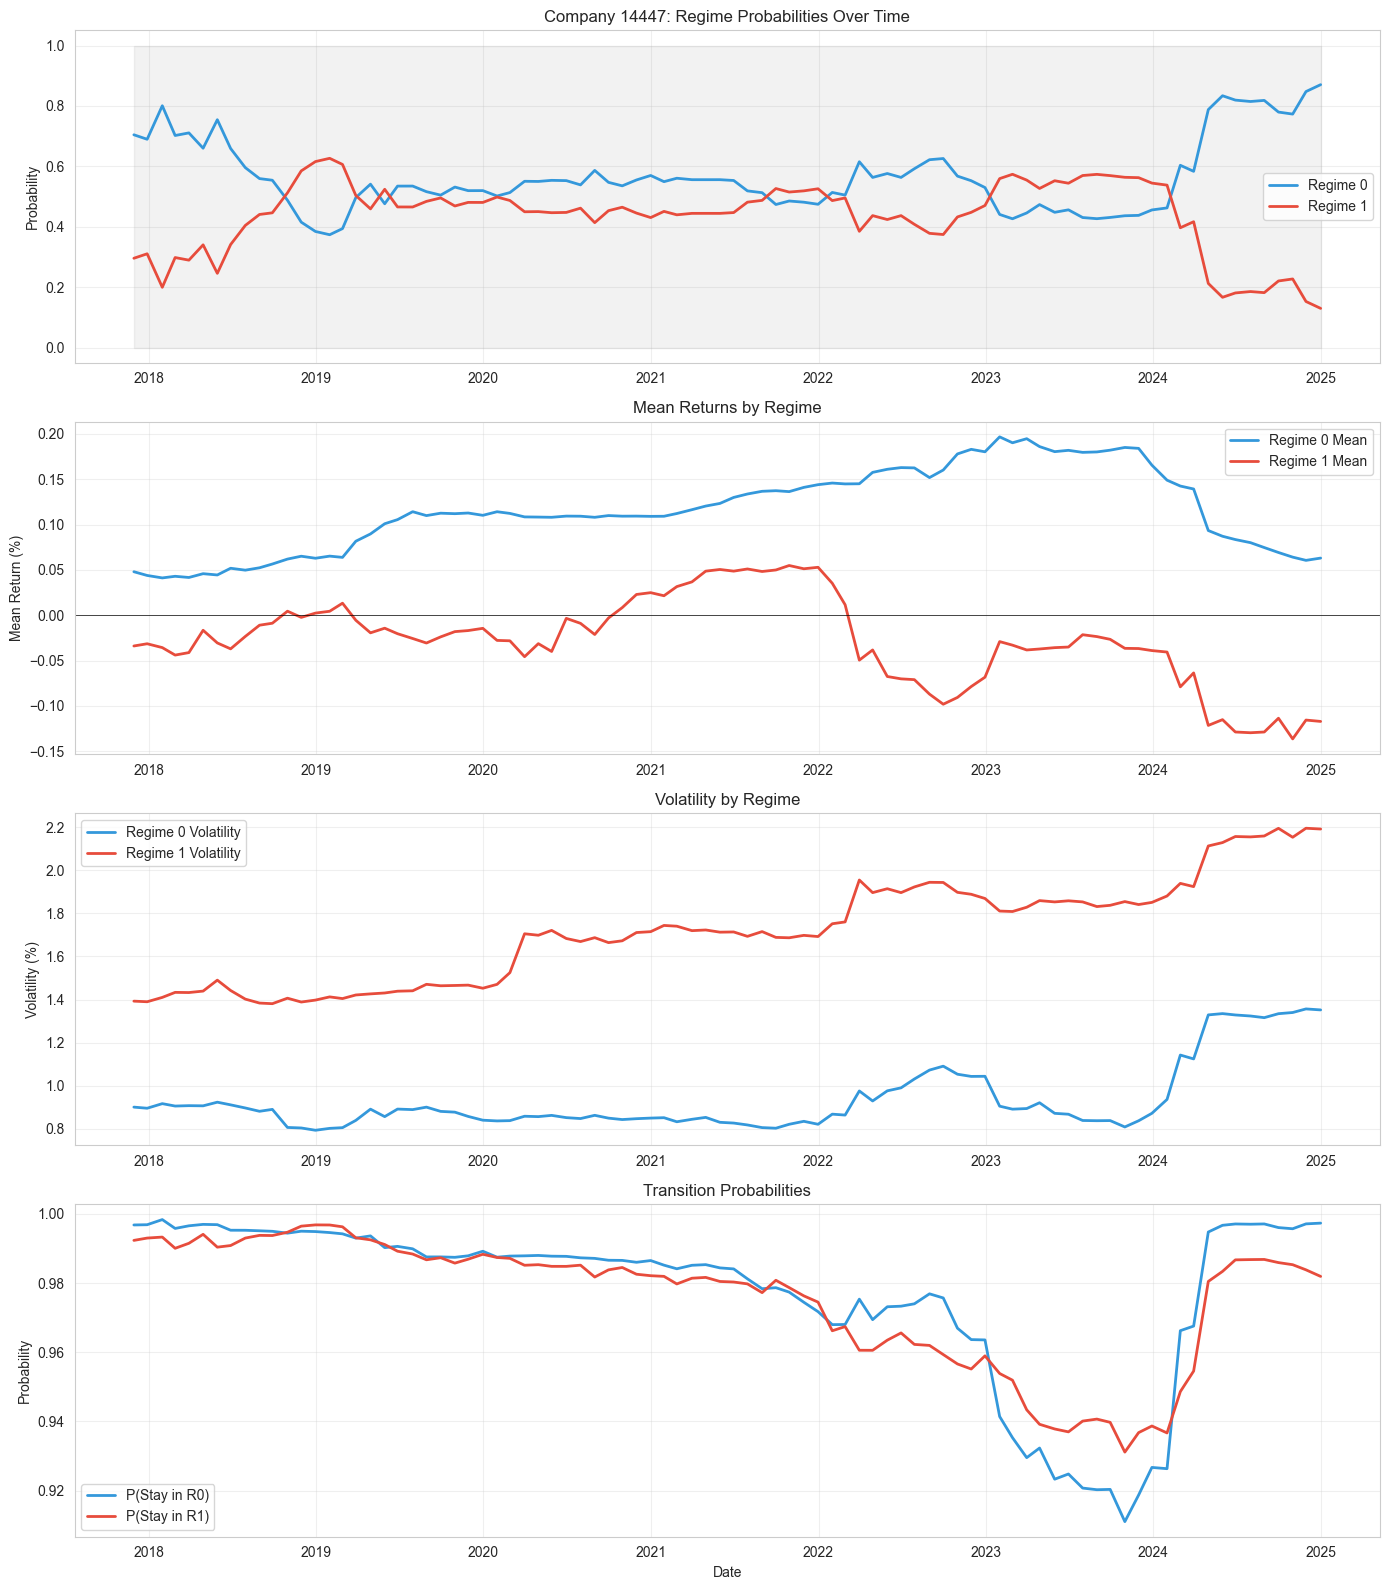

In [18]:
# Plot regime probabilities and parameters over time
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Regime probabilities
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_company['date'], 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'Company {sample_gvkey}: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean returns by regime
axes[1].plot(rs_company['date'], rs_company['regime_0_mean']*100, label='Regime 0 Mean', color='#3498db', linewidth=2)
axes[1].plot(rs_company['date'], rs_company['regime_1_mean']*100, label='Regime 1 Mean', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('Mean Returns by Regime')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Volatility by regime
axes[2].plot(rs_company['date'], rs_company['regime_0_vol']*100, label='Regime 0 Volatility', color='#3498db', linewidth=2)
axes[2].plot(rs_company['date'], rs_company['regime_1_vol']*100, label='Regime 1 Volatility', color='#e74c3c', linewidth=2)
axes[2].set_ylabel('Volatility (%)')
axes[2].set_title('Volatility by Regime')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Transition probabilities
axes[3].plot(rs_company['date'], rs_company['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[3].plot(rs_company['date'], rs_company['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[3].set_ylabel('Probability')
axes[3].set_xlabel('Date')
axes[3].set_title('Transition Probabilities')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Statistical Tests for Regime Differences

In [19]:
# Perform t-tests to check if regime parameters are significantly different
from scipy.stats import ttest_rel, ttest_ind

print('='*80)
print('REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(rs_params['regime_0_mean'], rs_params['regime_1_mean'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test volatility
t_stat, p_value = ttest_rel(rs_params['regime_0_vol'], rs_params['regime_1_vol'])
print(f"\nVolatility:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test degrees of freedom
t_stat, p_value = ttest_rel(rs_params['regime_0_nu'], rs_params['regime_1_nu'])
print(f"\nDegrees of Freedom (nu):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

print('\n' + '='*80)
print('MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(ms_garch['mu_0'], ms_garch['mu_1'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test GARCH parameters
t_stat, p_value = ttest_rel(ms_garch['alpha_0'], ms_garch['alpha_1'])
print(f"\nAlpha (ARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

t_stat, p_value = ttest_rel(ms_garch['beta_0'], ms_garch['beta_1'])
print(f"\nBeta (GARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: 31.4364
  p-value: 4.0520e-187
  Significant at 5% level: Yes

Volatility:
  t-statistic: -51.5247
  p-value: 0.0000e+00
  Significant at 5% level: Yes

Degrees of Freedom (nu):
  t-statistic: 2.1796
  p-value: 2.9370e-02
  Significant at 5% level: Yes

MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: -1.0703
  p-value: 2.8457e-01
  Significant at 5% level: No

Alpha (ARCH effect):
  t-statistic: -10.3833
  p-value: 7.9360e-25
  Significant at 5% level: Yes

Beta (GARCH effect):
  t-statistic: 11.2631
  p-value: 7.7710e-29
  Significant at 5% level: Yes


In [20]:
# Effect sizes (Cohen's d)
def cohens_d(x, y):
    """Calculate Cohen's d for effect size"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

print('='*80)
print('EFFECT SIZES (Cohen\'s d)')
print('='*80)
print("\nRegime Switching:")
print(f"  Mean Returns: d = {cohens_d(rs_params['regime_0_mean'], rs_params['regime_1_mean']):.4f}")
print(f"  Volatility: d = {cohens_d(rs_params['regime_0_vol'], rs_params['regime_1_vol']):.4f}")
print(f"  Degrees of Freedom: d = {cohens_d(rs_params['regime_0_nu'], rs_params['regime_1_nu']):.4f}")

print("\nMS-GARCH:")
print(f"  Mean Returns: d = {cohens_d(ms_garch['mu_0'], ms_garch['mu_1']):.4f}")
print(f"  Alpha: d = {cohens_d(ms_garch['alpha_0'], ms_garch['alpha_1']):.4f}")
print(f"  Beta: d = {cohens_d(ms_garch['beta_0'], ms_garch['beta_1']):.4f}")

print("\nInterpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect")

EFFECT SIZES (Cohen's d)

Regime Switching:
  Mean Returns: d = 0.8625
  Volatility: d = -1.2485
  Degrees of Freedom: d = 0.0578

MS-GARCH:
  Mean Returns: d = -0.0281
  Alpha: d = -0.2773
  Beta: d = 0.2207

Interpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect


## 10. Cross-Sectional Analysis Across Companies

In [21]:
# Compare characteristics across companies
company_stats_rs = rs_params.groupby('gvkey').agg({
    'regime_0_mean': 'mean',
    'regime_1_mean': 'mean',
    'regime_0_vol': 'mean',
    'regime_1_vol': 'mean',
    'steady_state_regime_0': 'mean',
    'steady_state_regime_1': 'mean',
    'duration_regime_0': 'mean',
    'duration_regime_1': 'mean'
}).reset_index()

# Add volatility ratio
company_stats_rs['vol_ratio'] = company_stats_rs['regime_1_vol'] / company_stats_rs['regime_0_vol']

print('Company-Level Statistics (Regime Switching):')
display(company_stats_rs.head(10))

Company-Level Statistics (Regime Switching):


,gvkey,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,steady_state_regime_0,steady_state_regime_1,duration_regime_0,duration_regime_1,vol_ratio
0,14447,0.001161,-0.000284,0.009343,0.017143,0.564793,0.435207,117.683044,73.673534,1.834867
1,15532,0.000015,-0.000080,0.000496,0.032577,0.865029,0.134971,62.016871,8.993333,65.721170
2,15549,0.000018,-0.000284,0.000708,0.029227,0.837941,0.162059,86.693108,14.100150,41.268737
3,15617,-0.001003,0.000017,0.000046,0.001137,0.011423,0.988577,1.234553,171.581683,24.794033
4,15677,0.000140,-0.000149,0.001172,0.005252,0.682548,0.317452,195.603749,77.447569,4.481217
5,15724,0.000086,-0.000118,0.000891,0.025841,0.741374,0.258626,68.463934,23.278870,29.009992
6,16348,0.000039,-0.000079,0.000953,0.018432,0.639601,0.360399,178.652843,161.013281,19.336128
7,17436,0.000080,-0.000541,0.007724,0.014913,0.759564,0.240436,368.052600,118.928281,1.930591
8,17452,0.000182,-0.000555,0.006742,0.011993,0.761397,0.238603,154.839442,50.141455,1.778760
9,19349,0.000321,-0.000087,0.006370,0.011279,0.557591,0.442409,262.128473,275.259328,1.770601


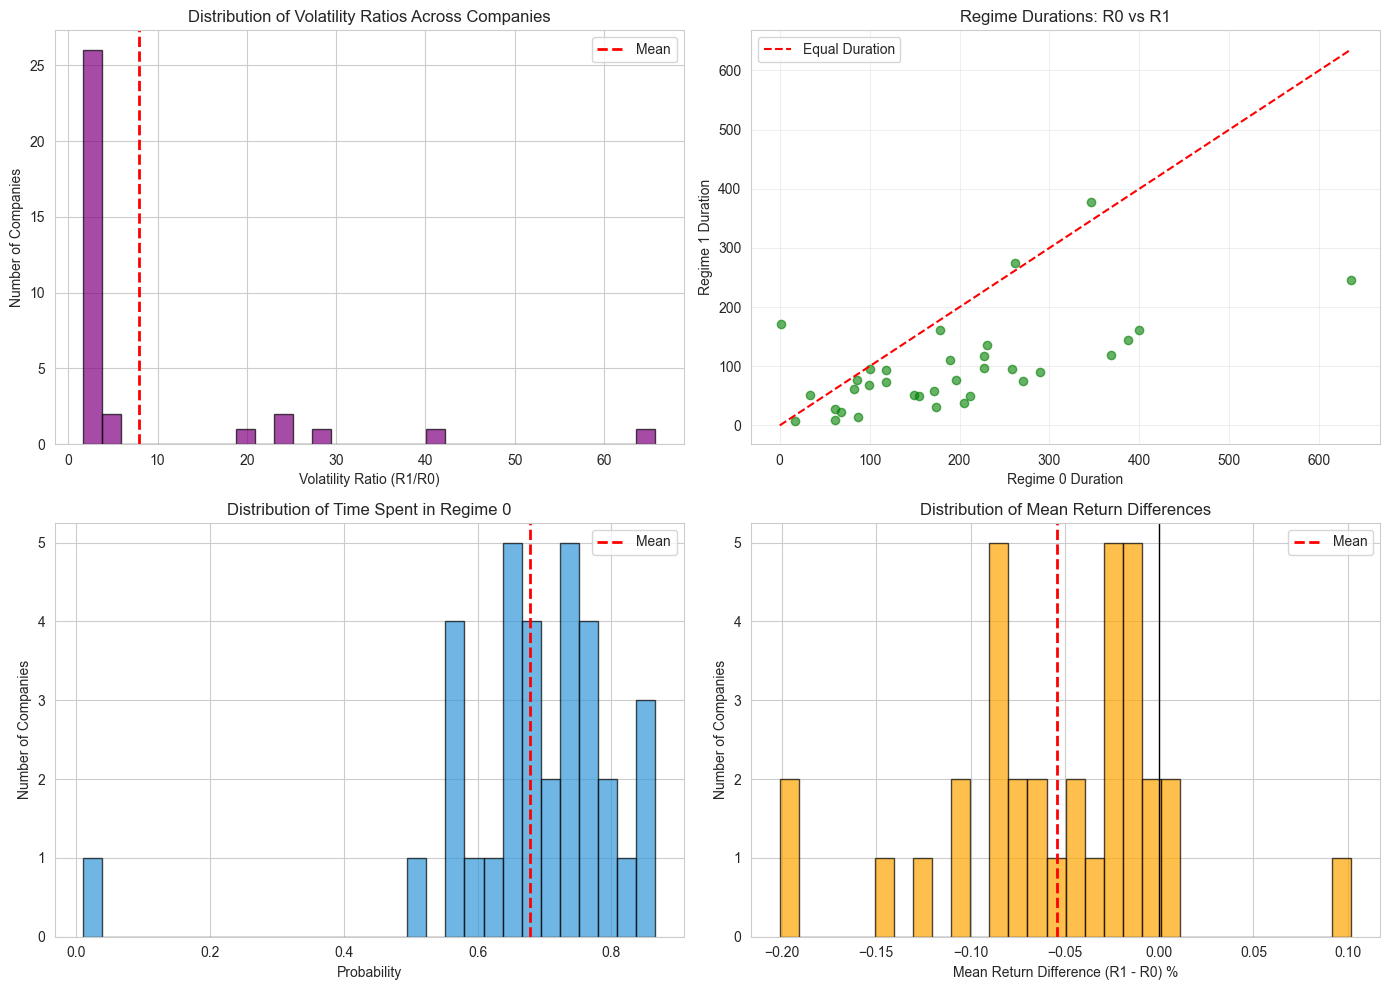

In [22]:
# Visualize company-level differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Volatility ratio across companies
axes[0, 0].hist(company_stats_rs['vol_ratio'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(company_stats_rs['vol_ratio'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Volatility Ratio (R1/R0)')
axes[0, 0].set_ylabel('Number of Companies')
axes[0, 0].set_title('Distribution of Volatility Ratios Across Companies')
axes[0, 0].legend()

# Duration comparison
axes[0, 1].scatter(company_stats_rs['duration_regime_0'], company_stats_rs['duration_regime_1'], alpha=0.6, color='green')
axes[0, 1].plot([0, company_stats_rs['duration_regime_0'].max()], [0, company_stats_rs['duration_regime_0'].max()], 'r--', label='Equal Duration')
axes[0, 1].set_xlabel('Regime 0 Duration')
axes[0, 1].set_ylabel('Regime 1 Duration')
axes[0, 1].set_title('Regime Durations: R0 vs R1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Regime frequency
axes[1, 0].hist(company_stats_rs['steady_state_regime_0'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(company_stats_rs['steady_state_regime_0'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Number of Companies')
axes[1, 0].set_title('Distribution of Time Spent in Regime 0')
axes[1, 0].legend()

# Mean return difference
company_stats_rs['mean_diff'] = company_stats_rs['regime_1_mean'] - company_stats_rs['regime_0_mean']
axes[1, 1].hist(company_stats_rs['mean_diff']*100, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(company_stats_rs['mean_diff'].mean()*100, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Mean Return Difference (R1 - R0) %')
axes[1, 1].set_ylabel('Number of Companies')
axes[1, 1].set_title('Distribution of Mean Return Differences')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [23]:
# Summary of key findings
print('='*80)
print('KEY FINDINGS SUMMARY')
print('='*80)

print('\n1. REGIME FREQUENCY:')
print(f"   - Average time in Regime 0 (RS): {rs_params['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (RS): {rs_params['steady_state_regime_1'].mean():.2%}")
print(f"   - Average time in Regime 0 (MS-GARCH): {ms_garch['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (MS-GARCH): {ms_garch['steady_state_regime_1'].mean():.2%}")

print('\n2. REGIME PERSISTENCE:')
print(f"   - Regime 0 expected duration (RS): {rs_params['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (RS): {rs_params['duration_regime_1'].mean():.2f} periods")
print(f"   - Regime 0 expected duration (MS-GARCH): {ms_garch['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (MS-GARCH): {ms_garch['duration_regime_1'].mean():.2f} periods")

print('\n3. PARAMETER DIFFERENCES:')
print(f"   - Mean return difference (RS): {(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%")
print(f"   - Volatility ratio (RS): {(rs_params['regime_1_vol'].mean() / rs_params['regime_0_vol'].mean()):.2f}x")
print(f"   - Mean return difference (MS-GARCH): {(ms_garch['mu_1'].mean() - ms_garch['mu_0'].mean())*100:.4f}%")

print('\n4. CROSS-SECTIONAL VARIATION:')
print(f"   - Volatility ratio std dev: {company_stats_rs['vol_ratio'].std():.2f}")
print(f"   - Companies with higher vol in R1: {(company_stats_rs['vol_ratio'] > 1).sum()} / {len(company_stats_rs)}")
print(f"   - Companies with positive mean diff: {(company_stats_rs['mean_diff'] > 0).sum()} / {len(company_stats_rs)}")

print('\n' + '='*80)

KEY FINDINGS SUMMARY

1. REGIME FREQUENCY:
   - Average time in Regime 0 (RS): 67.84%
   - Average time in Regime 1 (RS): 32.16%
   - Average time in Regime 0 (MS-GARCH): 63.45%
   - Average time in Regime 1 (MS-GARCH): 36.55%

2. REGIME PERSISTENCE:
   - Regime 0 expected duration (RS): 190.25 periods
   - Regime 1 expected duration (RS): 98.19 periods
   - Regime 0 expected duration (MS-GARCH): 83942.05 periods
   - Regime 1 expected duration (MS-GARCH): 31813.52 periods

3. PARAMETER DIFFERENCES:
   - Mean return difference (RS): -0.0540%
   - Volatility ratio (RS): 2.76x
   - Mean return difference (MS-GARCH): 0.0507%

4. CROSS-SECTIONAL VARIATION:
   - Volatility ratio std dev: 14.02
   - Companies with higher vol in R1: 34 / 34
   - Companies with positive mean diff: 3 / 34



## 11. Leverage Group Analysis

Analyze regime switching and MS-GARCH parameters across different leverage groups.
This helps understand if regime dynamics differ between high-leverage and low-leverage firms.

In [ ]:
# Load merged data to get leverage information
df_merged = pd.read_csv('data/output/merged_data_with_merton.csv')
df_merged['date'] = pd.to_datetime(df_merged['date'])

# Calculate leverage ratio
df_merged['leverage_ratio'] = df_merged['liabilities_total'] / (df_merged['liabilities_total'] + df_merged['mkt_cap'])

# Calculate average leverage for each firm
firm_leverage = df_merged.groupby('gvkey').agg({
    'leverage_ratio': 'mean',
    'company': 'first'
}).reset_index()

firm_leverage.columns = ['gvkey', 'avg_leverage', 'company']

# Create leverage terciles
firm_leverage['leverage_tercile'] = pd.qcut(
    firm_leverage['avg_leverage'], 
    q=3, 
    labels=['Low Leverage', 'Mid Leverage', 'High Leverage']
)

# Get tercile boundaries
tercile_boundaries = pd.qcut(firm_leverage['avg_leverage'], q=3, retbins=True)[1]

print("Leverage Group Definitions:")
print(f"Low Leverage:  < {tercile_boundaries[1]:.2%}")
print(f"Mid Leverage:  {tercile_boundaries[1]:.2%} - {tercile_boundaries[2]:.2%}")
print(f"High Leverage: > {tercile_boundaries[2]:.2%}")

# Create leverage mapping dictionary
leverage_group_map = firm_leverage.set_index('gvkey')['leverage_tercile'].to_dict()

# Add leverage groups to regime parameter dataframes
rs_params['leverage_tercile'] = rs_params['gvkey'].map(leverage_group_map)
ms_garch['leverage_tercile'] = ms_garch['gvkey'].map(leverage_group_map)

print(f"\n✓ Leverage groups assigned")
print(f"  Low Leverage: {(rs_params['leverage_tercile'] == 'Low Leverage').sum()} observations")
print(f"  Mid Leverage: {(rs_params['leverage_tercile'] == 'Mid Leverage').sum()} observations")
print(f"  High Leverage: {(rs_params['leverage_tercile'] == 'High Leverage').sum()} observations")

In [ ]:
# Regime frequency by leverage group
print('='*80)
print('REGIME FREQUENCY BY LEVERAGE GROUP')
print('='*80)

for model_name, df, col_prefix in [('Regime Switching', rs_params, 'steady_state_regime_'), 
                                     ('MS-GARCH', ms_garch, 'steady_state_regime_')]:
    print(f"\n{model_name}:")
    print(f"{'-'*80}")
    
    for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
        group_data = df[df['leverage_tercile'] == leverage_group]
        regime_0_prob = group_data[f'{col_prefix}0'].mean()
        regime_1_prob = group_data[f'{col_prefix}1'].mean()
        
        print(f"\n  {leverage_group}:")
        print(f"    Regime 0: {regime_0_prob:.2%}")
        print(f"    Regime 1: {regime_1_prob:.2%}")

In [ ]:
# Visualize regime frequency by leverage group
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors_r0 = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
colors_r1 = ['#27ae60', '#e67e22', '#c0392b']  # Darker shades

# Regime Switching
for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[0, idx]
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    regime_probs = [
        group_data['steady_state_regime_0'].mean(),
        group_data['steady_state_regime_1'].mean()
    ]
    
    bars = ax.bar(['Regime 0', 'Regime 1'], regime_probs, 
                   color=[colors_r0[idx], colors_r1[idx]], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'Regime Switching: {leverage_group}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    for i, v in enumerate(regime_probs):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# MS-GARCH
for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[1, idx]
    group_data = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    regime_probs = [
        group_data['steady_state_regime_0'].mean(),
        group_data['steady_state_regime_1'].mean()
    ]
    
    bars = ax.bar(['Regime 0', 'Regime 1'], regime_probs, 
                   color=[colors_r0[idx], colors_r1[idx]], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'MS-GARCH: {leverage_group}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    for i, v in enumerate(regime_probs):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Parameter comparison by leverage group - Regime Switching
print('='*80)
print('REGIME SWITCHING: PARAMETER COMPARISON BY LEVERAGE GROUP')
print('='*80)

rs_leverage_summary = []

for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    rs_leverage_summary.append({
        'Leverage Group': leverage_group,
        'Mean R0 (%)': group_data['regime_0_mean'].mean() * 100,
        'Mean R1 (%)': group_data['regime_1_mean'].mean() * 100,
        'Vol R0 (%)': group_data['regime_0_vol'].mean() * 100,
        'Vol R1 (%)': group_data['regime_1_vol'].mean() * 100,
        'Vol Ratio': group_data['regime_1_vol'].mean() / group_data['regime_0_vol'].mean(),
        'Duration R0': group_data['duration_regime_0'].mean(),
        'Duration R1': group_data['duration_regime_1'].mean(),
        'P(R0)': group_data['steady_state_regime_0'].mean(),
        'P(R1)': group_data['steady_state_regime_1'].mean()
    })

rs_leverage_df = pd.DataFrame(rs_leverage_summary)
display(rs_leverage_df.round(4))

In [ ]:
# Parameter comparison by leverage group - MS-GARCH
print('='*80)
print('MS-GARCH: PARAMETER COMPARISON BY LEVERAGE GROUP')
print('='*80)

ms_leverage_summary = []

for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    group_data = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    ms_leverage_summary.append({
        'Leverage Group': leverage_group,
        'Mean R0 (%)': group_data['mu_0'].mean() * 100,
        'Mean R1 (%)': group_data['mu_1'].mean() * 100,
        'Omega R0': group_data['omega_0'].mean(),
        'Omega R1': group_data['omega_1'].mean(),
        'Alpha R0': group_data['alpha_0'].mean(),
        'Alpha R1': group_data['alpha_1'].mean(),
        'Beta R0': group_data['beta_0'].mean(),
        'Beta R1': group_data['beta_1'].mean(),
        'Duration R0': group_data['duration_regime_0'].mean(),
        'Duration R1': group_data['duration_regime_1'].mean(),
        'P(R0)': group_data['steady_state_regime_0'].mean(),
        'P(R1)': group_data['steady_state_regime_1'].mean()
    })

ms_leverage_df = pd.DataFrame(ms_leverage_summary)
display(ms_leverage_df.round(6))

In [ ]:
# Visualize volatility by leverage group
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Regime Switching
ax = axes[0]
x = np.arange(len(leverage_groups))
width = 0.35

r0_vols = [rs_params[rs_params['leverage_tercile'] == lg]['regime_0_vol'].mean() * 100 
           for lg in leverage_groups]
r1_vols = [rs_params[rs_params['leverage_tercile'] == lg]['regime_1_vol'].mean() * 100 
           for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_vols, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_vols, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Volatility (%)', fontsize=12)
ax.set_title('Regime Switching: Volatility by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# MS-GARCH
ax = axes[1]
r0_vols_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['uncond_vol_0'].mean() * 100 
              for lg in leverage_groups]
r1_vols_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['uncond_vol_1'].mean() * 100 
              for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_vols_ms, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_vols_ms, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Unconditional Volatility (%)', fontsize=12)
ax.set_title('MS-GARCH: Volatility by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Visualize regime duration by leverage group
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
x = np.arange(len(leverage_groups))
width = 0.35

# Regime Switching
ax = axes[0]
r0_durations = [rs_params[rs_params['leverage_tercile'] == lg]['duration_regime_0'].mean() 
                for lg in leverage_groups]
r1_durations = [rs_params[rs_params['leverage_tercile'] == lg]['duration_regime_1'].mean() 
                for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_durations, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_durations, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Expected Duration (periods)', fontsize=12)
ax.set_title('Regime Switching: Regime Duration by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# MS-GARCH
ax = axes[1]
r0_durations_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['duration_regime_0'].mean() 
                   for lg in leverage_groups]
r1_durations_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['duration_regime_1'].mean() 
                   for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_durations_ms, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_durations_ms, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Expected Duration (periods)', fontsize=12)
ax.set_title('MS-GARCH: Regime Duration by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Distribution of volatility ratios by leverage group
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[idx]
    
    # Get volatility ratio for this group (Regime Switching)
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratios = group_data['regime_1_vol'] / group_data['regime_0_vol']
    
    ax.hist(vol_ratios, bins=30, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axvline(vol_ratios.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {vol_ratios.mean():.2f}')
    ax.axvline(vol_ratios.median(), color='blue', linestyle='--', linewidth=2, 
               label=f'Median: {vol_ratios.median():.2f}')
    
    ax.set_xlabel('Volatility Ratio (R1/R0)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{leverage_group}\n(Regime Switching)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print('Volatility Ratio Summary by Leverage Group (Regime Switching):')
print('='*80)
for leverage_group in leverage_groups:
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratios = group_data['regime_1_vol'] / group_data['regime_0_vol']
    
    print(f"\n{leverage_group}:")
    print(f"  Mean:   {vol_ratios.mean():.4f}")
    print(f"  Median: {vol_ratios.median():.4f}")
    print(f"  Std:    {vol_ratios.std():.4f}")
    print(f"  Min:    {vol_ratios.min():.4f}")
    print(f"  Max:    {vol_ratios.max():.4f}")

In [ ]:
# Summary of leverage group findings
print('='*80)
print('LEVERAGE GROUP ANALYSIS - KEY FINDINGS')
print('='*80)

print('\n1. REGIME FREQUENCY BY LEVERAGE:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    ms_group = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    print(f"\n  {leverage_group}:")
    print(f"    RS - Regime 0: {rs_group['steady_state_regime_0'].mean():.2%}, Regime 1: {rs_group['steady_state_regime_1'].mean():.2%}")
    print(f"    MS - Regime 0: {ms_group['steady_state_regime_0'].mean():.2%}, Regime 1: {ms_group['steady_state_regime_1'].mean():.2%}")

print('\n2. VOLATILITY PATTERNS:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratio = rs_group['regime_1_vol'].mean() / rs_group['regime_0_vol'].mean()
    
    print(f"\n  {leverage_group}:")
    print(f"    Regime 0 Vol: {rs_group['regime_0_vol'].mean()*100:.2f}%")
    print(f"    Regime 1 Vol: {rs_group['regime_1_vol'].mean()*100:.2f}%")
    print(f"    Volatility Ratio: {vol_ratio:.2f}x")

print('\n3. REGIME PERSISTENCE:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    print(f"\n  {leverage_group}:")
    print(f"    Regime 0 Duration: {rs_group['duration_regime_0'].mean():.1f} periods")
    print(f"    Regime 1 Duration: {rs_group['duration_regime_1'].mean():.1f} periods")

print('\n4. INTERPRETATION:')
print('  - High leverage firms may show different regime dynamics')
print('  - Volatility patterns may vary by capital structure')
print('  - Regime persistence could differ across leverage groups')
print('  - Consider leverage when interpreting regime-switching behavior')

print('\n' + '='*80)